# Generowanie danych stenosis jako obrócone fragmenty naczynia — wersja ALL/DEBUG

Ten notebook tworzy dataset do modułu 5 tak, jak opisałeś:

`obraz → segmentacja → maska → skeleton → junction decision cleanup → graf → fragmenty po ~10 px → obrócone prostokąty → label 0/1 z polygon segmentation ARCADE`

Najważniejsza poprawka względem poprzedniej wersji:

- funkcja podglądu domyślnie pokazuje **wszystkie** obrócone fragmenty dla danego `image_id`, a nie tylko okolice pozytywów,
- zapisuje debugowe maski/skeletony dla przetwarzanych obrazów,
- dodaje osobny panel diagnostyczny: oryginał + anotacje, maska, skeleton, wszystkie segmenty.

Kolory na wizualizacji:

- pomarańczowy = `label=0`, fragment bez stenozy,
- czerwony = `label=1`, fragment nachodzi na polygon segmentation stenozy,
- czarny prostokąt = oryginalny axis-aligned `bbox` z COCO/ARCADE, tylko referencyjnie,
- cyjan = polygon `segmentation` stenozy z `train.json`.


## 0. Importy podstawowe

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import math
import ast
import traceback
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from tqdm.auto import tqdm

from xgboost import XGBClassifier

## 1. Konfiguracja ścieżek

In [2]:
# Automatycznie znajdź root repozytorium.
cwd = Path.cwd().resolve()
REPO_ROOT = None
for c in [cwd, *cwd.parents]:
    if (c / "coronary-analysis").exists() and (c / "models").exists() and (c / "notebooks").exists():
        REPO_ROOT = c
        break

if REPO_ROOT is None:
    # Ustaw ręcznie, jeżeli automatyczne wyszukiwanie nie zadziała.
    REPO_ROOT = Path("/home/piotrrusak/Agh/coronary-stenosis-detection")

SRC_DIR = REPO_ROOT / "coronary-analysis" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ANNOTATION_JSON = (
    REPO_ROOT / "notebooks" / "raw_datasets" / "arcade" / "arcade" /
    "stenosis" / "train" / "annotations" / "train.json"
)

IMAGE_DIR = (
    REPO_ROOT / "notebooks" / "raw_datasets" / "arcade" / "arcade" /
    "stenosis" / "train" / "images"
)

MODEL_PATH = REPO_ROOT / "models" / "best_segmentation_model.pth"

OUTPUT_DIR = REPO_ROOT / "notebooks" / "processed" / "stenosis_oriented_segments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:      ", REPO_ROOT)
print("SRC_DIR:        ", SRC_DIR)
print("ANNOTATION_JSON:", ANNOTATION_JSON)
print("IMAGE_DIR:      ", IMAGE_DIR)
print("MODEL_PATH:     ", MODEL_PATH)
print("OUTPUT_DIR:     ", OUTPUT_DIR)

assert ANNOTATION_JSON.exists(), f"Nie znaleziono train.json: {ANNOTATION_JSON}"
assert IMAGE_DIR.exists(), f"Nie znaleziono katalogu obrazów: {IMAGE_DIR}"
assert MODEL_PATH.exists(), f"Nie znaleziono wag modelu: {MODEL_PATH}"

print("\nOK — ścieżki istnieją.")


REPO_ROOT:       /home/piotrrusak/Agh/coronary-stenosis-detection
SRC_DIR:         /home/piotrrusak/Agh/coronary-stenosis-detection/coronary-analysis/src
ANNOTATION_JSON: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/raw_datasets/arcade/arcade/stenosis/train/annotations/train.json
IMAGE_DIR:       /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/raw_datasets/arcade/arcade/stenosis/train/images
MODEL_PATH:      /home/piotrrusak/Agh/coronary-stenosis-detection/models/best_segmentation_model.pth
OUTPUT_DIR:      /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments

OK — ścieżki istnieją.


## 2. Importy z biblioteki projektu

Ta komórka korzysta z funkcji repozytorium do segmentacji, skeletonizacji, budowy grafu i junction decision cleanupu.

In [3]:
import torch

from coronary_analysis.inference import load_image, load_segmentation_model, predict_mask
from coronary_analysis.topology import (
    build_vessel_graph,
    clean_mask,
    compute_distance_map,
    estimate_branch_diameters,
    prune_skeleton,
    skeletonize_mask,
)
from coronary_analysis.topology.junction_decision import (
    DEFAULT_JUNCTION_DECISION_CONFIG,
    run_junction_decision,
)
from coronary_analysis.topology.junction_decision.graph_cleanup import (
    remove_false_junctions_from_skeleton,
)
from coronary_analysis.utils import get_device

print("Importy z coronary_analysis OK")
DEFAULT_JUNCTION_DECISION_CONFIG


Importy z coronary_analysis OK


JunctionDecisionConfig(junction_group_dilation=3, min_junction_area=1, remove_radius=2, max_arm_steps=60, min_arm_len=4, enable_local_refine=True, local_crop_size=80, local_remove_radius=2, local_max_arm_steps=80, local_min_arm_len=2, local_keep_short_arms=True, local_prune_min_branch_length=2, fake_mean_cost_threshold=0.25, fake_max_cost_threshold=0.4, allow_two_arm_fake=True, min_area_for_two_arm_fake=6, enable_thickness_fake=True, thickness_radius=5, thickness_fake_threshold=2.0, thickness_fake_max_extra=1.0, thickness_area_threshold=4, soft_false_mean_cost_extra=0.15, graph_cleanup_neighbor_score_threshold=0.3, max_pairing_arms=8, graph_cleanup_max_center_distance=8.0)

## 3. Parametry pipeline'u

In [4]:
ENCODER_NAME = "resnet34"
IMG_SIZE = 256
SEGMENTATION_THRESHOLD = 0.5

MASK_CLOSING_RADIUS = 2
MASK_MAX_HOLE_SIZE = 50
MASK_MIN_OBJECT_SIZE = 50
PRUNE_MIN_BRANCH_LENGTH = 15

JUNCTION_DECISION_CONFIG = DEFAULT_JUNCTION_DECISION_CONFIG
USE_JUNCTION_DECISION_CLEANUP = True

SEGMENT_LENGTH_PX = 10.0
SEGMENT_STEP_PX = 10.0
MIN_SEGMENT_LENGTH_PX = 4.0
CENTERLINE_SAMPLE_STEP_PX = 1.0
WIDTH_SCALE = 1.15
MIN_PATCH_WIDTH_PX = 4.0
MAX_PATCH_WIDTH_PX = 40.0

POSITIVE_PATCH_OVERLA30P_FRACTION = 0.03

FAST_DEV_LIMIT = None

SAVE_PATCH_PIXELS = True
SAVE_CENTERLINE_POINTS = True
SAVE_DEBUG_IMAGES = True
DEBUG_DIR = OUTPUT_DIR / "debug_pipeline"
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = get_device()
print("DEVICE:", DEVICE)
print("DEBUG_DIR:", DEBUG_DIR)


DEVICE: cpu
DEBUG_DIR: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline


## 4. Wczytanie anotacji ARCADE i zbudowanie masek `segmentation`

Używamy przede wszystkim pola `segmentation`, a nie samego `bbox`. `bbox` zostaje tylko jako debug/fallback, gdyby polygon segmentation było puste.

In [5]:
with open(ANNOTATION_JSON, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco.get("categories", [])

image_by_id = {int(img["id"]): img for img in images}
image_id_by_file = {img["file_name"]: int(img["id"]) for img in images}


def coco_segmentation_to_mask(segmentation, height: int, width: int) -> np.ndarray:
    """COCO polygon segmentation -> maska binarna HxW.

    Obsługuje typowy format ARCADE: list[list[x1,y1,x2,y2,...]].
    Jeżeli segmentation jest puste albo RLE, zwraca pustą maskę.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    if segmentation is None:
        return mask

    if isinstance(segmentation, list):
        for poly in segmentation:
            if poly is None or len(poly) < 6:
                continue
            pts = np.asarray(poly, dtype=np.float32).reshape(-1, 2)
            if len(pts) < 3:
                continue
            pts_i = np.round(pts).astype(np.int32)
            pts_i[:, 0] = np.clip(pts_i[:, 0], 0, width - 1)
            pts_i[:, 1] = np.clip(pts_i[:, 1], 0, height - 1)
            cv2.fillPoly(mask, [pts_i], 1)

    return mask


anns_by_image = defaultdict(list)
stenosis_mask_by_image = {}
ann_masks_by_image = defaultdict(list)

for ann in annotations:
    image_id = int(ann["image_id"])
    img_info = image_by_id[image_id]
    h = int(img_info["height"])
    w = int(img_info["width"])

    if image_id not in stenosis_mask_by_image:
        stenosis_mask_by_image[image_id] = np.zeros((h, w), dtype=np.uint8)

    x, y, bw, bh = ann["bbox"]
    bbox_xywh = [float(x), float(y), float(bw), float(bh)]
    bbox_xyxy = [float(x), float(y), float(x + bw), float(y + bh)]

    seg_mask = coco_segmentation_to_mask(ann.get("segmentation"), h, w)

    used_bbox_fallback = False
    if seg_mask.sum() == 0:
        x1 = max(0, min(int(round(x)), w - 1))
        y1 = max(0, min(int(round(y)), h - 1))
        x2 = max(0, min(int(round(x + bw)), w))
        y2 = max(0, min(int(round(y + bh)), h))
        seg_mask[y1:y2, x1:x2] = 1
        used_bbox_fallback = True

    ann2 = dict(ann)
    ann2["bbox_xywh"] = bbox_xywh
    ann2["bbox_xyxy"] = bbox_xyxy
    ann2["used_bbox_fallback"] = used_bbox_fallback

    anns_by_image[image_id].append(ann2)
    ann_masks_by_image[image_id].append({
        "ann_id": int(ann["id"]),
        "mask": seg_mask,
        "bbox_xywh": bbox_xywh,
        "bbox_xyxy": bbox_xyxy,
        "used_bbox_fallback": used_bbox_fallback,
    })
    stenosis_mask_by_image[image_id] = np.maximum(stenosis_mask_by_image[image_id], seg_mask)

print("images:", len(images))
print("annotations:", len(annotations))
print("categories:", categories)
print("images with stenosis annotations:", len(anns_by_image))
print("images with stenosis masks:", len(stenosis_mask_by_image))

pd.DataFrame(images).head()


images: 1000
annotations: 1625
categories: [{'id': 1, 'name': '1', 'supercategory': ''}, {'id': 2, 'name': '2', 'supercategory': ''}, {'id': 3, 'name': '3', 'supercategory': ''}, {'id': 4, 'name': '4', 'supercategory': ''}, {'id': 5, 'name': '5', 'supercategory': ''}, {'id': 6, 'name': '6', 'supercategory': ''}, {'id': 7, 'name': '7', 'supercategory': ''}, {'id': 8, 'name': '8', 'supercategory': ''}, {'id': 9, 'name': '9', 'supercategory': ''}, {'id': 10, 'name': '9a', 'supercategory': ''}, {'id': 11, 'name': '10', 'supercategory': ''}, {'id': 12, 'name': '10a', 'supercategory': ''}, {'id': 13, 'name': '11', 'supercategory': ''}, {'id': 14, 'name': '12', 'supercategory': ''}, {'id': 15, 'name': '12a', 'supercategory': ''}, {'id': 16, 'name': '13', 'supercategory': ''}, {'id': 17, 'name': '14', 'supercategory': ''}, {'id': 18, 'name': '14a', 'supercategory': ''}, {'id': 19, 'name': '15', 'supercategory': ''}, {'id': 20, 'name': '16', 'supercategory': ''}, {'id': 21, 'name': '16a', 'supe

,id,width,height,file_name,license,flickr_url,coco_url,date_captured
0,676,512,512,676.png,0,,,0
1,960,512,512,960.png,0,,,0
2,99,512,512,99.png,0,,,0
3,672,512,512,672.png,0,,,0
4,7,512,512,7.png,0,,,0


## 5. Załadowanie modelu segmentacji

In [6]:
model = load_segmentation_model(
    str(MODEL_PATH),
    device=DEVICE,
    encoder_name=ENCODER_NAME,
)
model.eval()
print("Model segmentacji załadowany:", MODEL_PATH)


Model segmentacji załadowany: /home/piotrrusak/Agh/coronary-stenosis-detection/models/best_segmentation_model.pth


## 6. Funkcje pomocnicze do geometrii obróconych fragmentów

In [7]:
def yx_to_xy(points_yx: np.ndarray) -> np.ndarray:
    pts = np.asarray(points_yx, dtype=float)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return np.empty((0, 2), dtype=float)
    return np.column_stack([pts[:, 1], pts[:, 0]])


def xy_to_yx(points_xy: np.ndarray) -> np.ndarray:
    pts = np.asarray(points_xy, dtype=float)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return np.empty((0, 2), dtype=float)
    return np.column_stack([pts[:, 1], pts[:, 0]])


def polyline_length(points: np.ndarray) -> float:
    pts = np.asarray(points, dtype=float)
    if len(pts) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(pts, axis=0), axis=1).sum())


def cumulative_lengths(points: np.ndarray) -> np.ndarray:
    pts = np.asarray(points, dtype=float)
    if len(pts) == 0:
        return np.array([0.0])
    if len(pts) == 1:
        return np.array([0.0])
    seg_lens = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    return np.concatenate([[0.0], np.cumsum(seg_lens)])


def interpolate_along_polyline(points: np.ndarray, distances: np.ndarray) -> np.ndarray:
    """Interpolacja punktów po łamanej w zadanych odległościach od początku."""
    pts = np.asarray(points, dtype=float)
    distances = np.asarray(distances, dtype=float)

    if len(pts) == 0:
        return np.empty((0, 2), dtype=float)
    if len(pts) == 1:
        return np.repeat(pts, len(distances), axis=0)

    cum = cumulative_lengths(pts)
    total = cum[-1]
    seg_lens = np.diff(cum)

    out = []
    for d in distances:
        d = float(np.clip(d, 0.0, total))
        idx = np.searchsorted(cum, d, side="right") - 1
        idx = min(max(idx, 0), len(seg_lens) - 1)
        if seg_lens[idx] <= 1e-8:
            out.append(pts[idx])
        else:
            t = (d - cum[idx]) / seg_lens[idx]
            out.append(pts[idx] + t * (pts[idx + 1] - pts[idx]))
    return np.asarray(out, dtype=float)


def segment_distance_ranges(total_length: float,
                            segment_length: float = SEGMENT_LENGTH_PX,
                            step: float = SEGMENT_STEP_PX,
                            min_length: float = MIN_SEGMENT_LENGTH_PX):
    """Zwraca przedziały [d0, d1] po centerline."""
    if total_length < min_length:
        return []

    ranges = []
    d0 = 0.0
    while d0 < total_length:
        d1 = min(d0 + segment_length, total_length)
        if d1 - d0 >= min_length:
            ranges.append((float(d0), float(d1)))
        if d1 >= total_length:
            break
        d0 += step
    return ranges


def sample_centerline_segment(path_xy: np.ndarray, d0: float, d1: float) -> np.ndarray:
    n_samples = max(3, int(math.ceil((d1 - d0) / CENTERLINE_SAMPLE_STEP_PX)) + 1)
    distances = np.linspace(d0, d1, n_samples)
    return interpolate_along_polyline(path_xy, distances)


def local_diameters_for_centerline(centerline_xy: np.ndarray, dist_map: np.ndarray) -> np.ndarray:
    """Średnica ~ 2 * distance transform w punktach centerline."""
    pts = np.asarray(centerline_xy, dtype=float)
    if len(pts) == 0:
        return np.array([np.nan], dtype=float)

    h, w = dist_map.shape[:2]
    xs = np.clip(np.round(pts[:, 0]).astype(int), 0, w - 1)
    ys = np.clip(np.round(pts[:, 1]).astype(int), 0, h - 1)
    return 2.0 * np.asarray(dist_map[ys, xs], dtype=float)


def oriented_rectangle_from_centerline(centerline_xy: np.ndarray, width_px: float) -> tuple[np.ndarray, float]:
    """Tworzy obrócony prostokąt wokół fragmentu centerline.

    Zwraca:
    - vertices_xy: ndarray [4,2] w kolejności [start_left, end_left, end_right, start_right]
    - angle_deg: kąt osi fragmentu względem osi X obrazu
    """
    pts = np.asarray(centerline_xy, dtype=float)
    if len(pts) < 2:
        return None, np.nan

    p0 = pts[0]
    p1 = pts[-1]
    direction = p1 - p0
    norm = np.linalg.norm(direction)
    if norm <= 1e-8:
        return None, np.nan

    direction = direction / norm
    normal = np.array([-direction[1], direction[0]], dtype=float)
    half_w = float(width_px) / 2.0

    vertices = np.array([
        p0 + normal * half_w,
        p1 + normal * half_w,
        p1 - normal * half_w,
        p0 - normal * half_w,
    ], dtype=float)

    angle_deg = float(np.degrees(np.arctan2(direction[1], direction[0])))
    return vertices, angle_deg


def polygon_to_mask(poly_xy: np.ndarray, height: int, width: int) -> np.ndarray:
    mask = np.zeros((height, width), dtype=np.uint8)
    poly = np.asarray(poly_xy, dtype=np.float32)
    if poly.ndim != 2 or poly.shape[0] < 3:
        return mask
    poly_i = np.round(poly).astype(np.int32)
    poly_i[:, 0] = np.clip(poly_i[:, 0], 0, width - 1)
    poly_i[:, 1] = np.clip(poly_i[:, 1], 0, height - 1)
    cv2.fillPoly(mask, [poly_i], 1)
    return mask


def mask_pixels_xy(mask: np.ndarray) -> list[list[int]]:
    ys, xs = np.where(mask > 0)
    return [[int(x), int(y)] for x, y in zip(xs, ys)]


def safe_branch_diameters(path_yx: np.ndarray, dist_map: np.ndarray) -> np.ndarray:
    try:
        d = estimate_branch_diameters(path_yx, dist_map)
        d = np.asarray(d, dtype=float)
        if len(d) == 0:
            return np.array([np.nan], dtype=float)
        return d
    except Exception:
        path_xy = yx_to_xy(path_yx)
        return local_diameters_for_centerline(path_xy, dist_map)


def match_patch_to_annotations(patch_mask: np.ndarray, image_id: int):
    """Sprawdza przecięcie patcha z polygon segmentation każdej anotacji stenosis."""
    patch_area = int(patch_mask.sum())
    if patch_area == 0:
        return 0, [], [], 0.0, 0

    matched_ids = []
    matched_bboxes = []
    max_overlap_fraction = 0.0
    max_intersection_area = 0

    for annm in ann_masks_by_image.get(int(image_id), []):
        inter = int(np.logical_and(patch_mask > 0, annm["mask"] > 0).sum())
        if inter <= 0:
            continue
        frac = inter / float(patch_area)
        matched_ids.append(int(annm["ann_id"]))
        matched_bboxes.append(annm["bbox_xywh"])
        max_overlap_fraction = max(max_overlap_fraction, frac)
        max_intersection_area = max(max_intersection_area, inter)

    label = int(max_overlap_fraction >= POSITIVE_PATCH_OVERLAP_FRACTION)
    return label, matched_ids, matched_bboxes, float(max_overlap_fraction), int(max_intersection_area)


## 7. Pipeline dla jednego obrazu: maska → skeleton → junction cleanup → graf

In [8]:
def process_image_with_junction_graph(image_path: Path, image_id: int | None = None) -> dict:
    image = load_image(image_path)

    mask = predict_mask(
        image,
        model,
        device=DEVICE,
        img_size=IMG_SIZE,
        threshold=SEGMENTATION_THRESHOLD,
    )

    mask = clean_mask(
        mask,
        closing_radius=MASK_CLOSING_RADIUS,
        max_hole_size=MASK_MAX_HOLE_SIZE,
        min_object_size=MASK_MIN_OBJECT_SIZE,
    ).astype(bool)

    skeleton_raw = skeletonize_mask(mask).astype(bool)
    skeleton_pruned = prune_skeleton(
        skeleton_raw,
        min_branch_length=PRUNE_MIN_BRANCH_LENGTH,
    ).astype(bool)

    dist_map = compute_distance_map(mask)

    junction_decision = run_junction_decision(
        image=image,
        mask_clean=mask,
        skeleton=skeleton_pruned,
        distance_map=dist_map,
        config=JUNCTION_DECISION_CONFIG,
    )

    if USE_JUNCTION_DECISION_CLEANUP:
        skeleton_final, cleanup_info = remove_false_junctions_from_skeleton(
            skeleton=skeleton_pruned,
            junction_decision=junction_decision,
            config=JUNCTION_DECISION_CONFIG,
        )
        skeleton_final = skeleton_final.astype(bool)
    else:
        skeleton_final = skeleton_pruned
        cleanup_info = None

    skel_obj, branch_data = build_vessel_graph(skeleton_final)

    if SAVE_DEBUG_IMAGES and image_id is not None:
        try:
            DEBUG_DIR.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_mask.png"), (mask.astype(np.uint8) * 255))
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_skeleton_raw.png"), (skeleton_raw.astype(np.uint8) * 255))
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_skeleton_pruned.png"), (skeleton_pruned.astype(np.uint8) * 255))
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_skeleton_final.png"), (skeleton_final.astype(np.uint8) * 255))
        except Exception as e:
            print("Nie udało się zapisać debug images:", repr(e))

    return {
        "image": image,
        "mask": mask,
        "skeleton_raw": skeleton_raw,
        "skeleton_pruned": skeleton_pruned,
        "skeleton_final": skeleton_final,
        "distance_map": dist_map,
        "junction_decision": junction_decision,
        "cleanup_info": cleanup_info,
        "skel_obj": skel_obj,
        "branch_data": branch_data,
    }


def junction_counts(junction_decision) -> dict:
    try:
        return dict(junction_decision.counts)
    except Exception:
        counts = defaultdict(int)
        for d in getattr(junction_decision, "decisions", []):
            label = getattr(getattr(d, "label", None), "value", str(getattr(d, "label", "unknown")))
            counts[label] += 1
        return dict(counts)


## 8. Zamiana grafu jednego obrazu na obrócone fragmenty po ~10 px

In [9]:
def image_to_oriented_segment_rows(image_rec: dict) -> list[dict]:
    image_id = int(image_rec["id"])
    file_name = image_rec["file_name"]
    image_path = IMAGE_DIR / file_name

    out = process_image_with_junction_graph(image_path, image_id=image_id)
    skel_obj = out["skel_obj"]
    branch_data = out["branch_data"]
    dist_map = out["distance_map"]
    counts = junction_counts(out["junction_decision"])

    h, w = dist_map.shape[:2]
    rows = []
    global_segment_id = 0

    for branch_id in range(len(branch_data)):
        try:
            path_yx = np.asarray(skel_obj.path_coordinates(branch_id), dtype=float)
        except Exception:
            continue

        if len(path_yx) < 2:
            continue

        path_xy = yx_to_xy(path_yx)
        total_len = polyline_length(path_xy)
        if total_len < MIN_SEGMENT_LENGTH_PX:
            continue

        branch_row = branch_data.iloc[branch_id].to_dict()
        branch_len = float(branch_row.get("branch_distance", total_len))
        euclidean = float(branch_row.get("euclidean_distance", np.nan))
        if not np.isfinite(euclidean) or euclidean <= 0:
            euclidean = np.linalg.norm(path_xy[-1] - path_xy[0])
        tortuosity = float(branch_len / euclidean) if np.isfinite(euclidean) and euclidean > 0 else np.nan

        branch_diam = safe_branch_diameters(path_yx, dist_map)

        for local_segment_id, (d0, d1) in enumerate(segment_distance_ranges(total_len)):
            centerline_xy = sample_centerline_segment(path_xy, d0, d1)
            segment_len = polyline_length(centerline_xy)
            if segment_len < MIN_SEGMENT_LENGTH_PX:
                continue

            local_diam = local_diameters_for_centerline(centerline_xy, dist_map)
            mean_d = float(np.nanmean(local_diam)) if np.isfinite(local_diam).any() else float(np.nanmean(branch_diam))
            min_d = float(np.nanmin(local_diam)) if np.isfinite(local_diam).any() else float(np.nanmin(branch_diam))
            max_d = float(np.nanmax(local_diam)) if np.isfinite(local_diam).any() else float(np.nanmax(branch_diam))
            std_d = float(np.nanstd(local_diam)) if np.isfinite(local_diam).any() else float(np.nanstd(branch_diam))

            if not np.isfinite(mean_d) or mean_d <= 0:
                mean_d = MIN_PATCH_WIDTH_PX / WIDTH_SCALE

            patch_width = float(np.clip(mean_d * WIDTH_SCALE, MIN_PATCH_WIDTH_PX, MAX_PATCH_WIDTH_PX))
            vertices_xy, angle_deg = oriented_rectangle_from_centerline(centerline_xy, patch_width)
            if vertices_xy is None:
                continue

            patch_mask = polygon_to_mask(vertices_xy, h, w)
            patch_area = int(patch_mask.sum())
            if patch_area == 0:
                continue

            label, matched_ids, matched_bboxes, overlap_frac, intersection_area = match_patch_to_annotations(patch_mask, image_id)

            cx = float(np.mean(centerline_xy[:, 0]))
            cy = float(np.mean(centerline_xy[:, 1]))
            x_min = float(np.min(vertices_xy[:, 0]))
            y_min = float(np.min(vertices_xy[:, 1]))
            x_max = float(np.max(vertices_xy[:, 0]))
            y_max = float(np.max(vertices_xy[:, 1]))

            row = {
                "image_id": image_id,
                "file_name": file_name,
                "branch_id": int(branch_id),
                "oriented_segment_id": int(global_segment_id),
                "local_segment_id": int(local_segment_id),
                "arc_start_px": float(d0),
                "arc_end_px": float(d1),
                "center_x": cx,
                "center_y": cy,
                "segment_length_px": float(segment_len),
                "patch_width_px": float(patch_width),
                "patch_area_px": int(patch_area),
                "angle_deg": float(angle_deg),
                "oriented_box_vertices_xy": json.dumps(vertices_xy.round(2).tolist()),
                "axis_bbox_x_min": x_min,
                "axis_bbox_y_min": y_min,
                "axis_bbox_x_max": x_max,
                "axis_bbox_y_max": y_max,
                "axis_bbox_width": x_max - x_min,
                "axis_bbox_height": y_max - y_min,
                "mean_diameter": mean_d,
                "min_diameter": min_d,
                "max_diameter": max_d,
                "std_diameter": std_d,
                "diameter_drop": float((mean_d - min_d) / (mean_d + 1e-8)),
                "branch_distance": branch_len,
                "branch_euclidean_distance": float(euclidean),
                "branch_tortuosity": tortuosity,
                "branch_type": int(branch_row.get("branch_type", -1)) if pd.notna(branch_row.get("branch_type", np.nan)) else -1,
                "label": int(label),
                "matched_annotation_ids": ";".join(map(str, matched_ids)),
                "matched_annotation_bboxes_xywh": json.dumps(matched_bboxes),
                "positive_patch_overlap_fraction": float(overlap_frac),
                "positive_patch_intersection_area_px": int(intersection_area),
                "n_junction_certain": int(counts.get("certain", 0)),
                "n_junction_false": int(counts.get("false", 0)),
                "n_junction_not": int(counts.get("not", 0)),
                "used_junction_cleanup": bool(USE_JUNCTION_DECISION_CLEANUP),
            }

            if SAVE_CENTERLINE_POINTS:
                row["centerline_points_xy"] = json.dumps(centerline_xy.round(2).tolist())

            if SAVE_PATCH_PIXELS:
                row["patch_pixels_xy"] = json.dumps(mask_pixels_xy(patch_mask))

            rows.append(row)
            global_segment_id += 1

    return rows


## 9. Test na jednym obrazie z anotacją

In [10]:
test_image_id = next(iter(anns_by_image.keys()))
test_rec = image_by_id[test_image_id]
print("Test image:", test_rec)

POSITIVE_PATCH_OVERLAP_FRACTION = 0.10
test_rows = image_to_oriented_segment_rows(test_rec)
print("rows:", len(test_rows))
test_df = pd.DataFrame(test_rows)
print(test_df["label"].value_counts(dropna=False) if len(test_df) else "empty")
test_df.head()


Test image: {'id': 676, 'width': 512, 'height': 512, 'file_name': '676.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
rows: 175
label
0    165
1     10
Name: count, dtype: int64


,image_id,file_name,branch_id,oriented_segment_id,local_segment_id,arc_start_px,arc_end_px,center_x,center_y,segment_length_px,...,matched_annotation_ids,matched_annotation_bboxes_xywh,positive_patch_overlap_fraction,positive_patch_intersection_area_px,n_junction_certain,n_junction_false,n_junction_not,used_junction_cleanup,centerline_points_xy,patch_pixels_xy
0,676,676.png,0,0,0,0.0,10.000000,220.122104,34.394831,9.797063,...,,[],0.0,0,13,2,0,True,"[[220.0, 30.0], [220.0, 31.0], [220.71, 31.71]...","[[218, 30], [219, 30], [220, 30], [221, 30], [..."
1,676,676.png,0,1,1,10.0,20.000000,218.747439,43.652745,9.807937,...,,[],0.0,0,13,2,0,True,"[[219.0, 38.76], [219.0, 39.76], [219.0, 40.76...","[[216, 38], [217, 38], [218, 38], [219, 38], [..."
2,676,676.png,0,2,2,20.0,30.000000,215.721596,52.399400,9.842086,...,,[],0.0,0,13,2,0,True,"[[217.76, 48.24], [217.05, 48.95], [217.0, 49....","[[214, 47], [215, 47], [213, 48], [214, 48], [..."
3,676,676.png,0,3,3,30.0,36.556349,212.555456,59.366117,6.293488,...,,[],0.0,0,13,2,0,True,"[[214.0, 56.69], [213.56, 57.44], [213.0, 58.1...","[[209, 54], [208, 55], [209, 55], [210, 55], [..."
4,676,676.png,1,4,0,0.0,10.000000,241.423350,39.022058,9.852419,...,,[],0.0,0,13,2,0,True,"[[246.0, 38.0], [245.29, 38.71], [244.41, 39.0...","[[243, 36], [244, 36], [245, 36], [239, 37], [..."


## 10. Generowanie DataFrame'u dla wielu obrazów

In [11]:
image_records = list(images)

image_records = sorted(
    image_records,
    key=lambda r: (0 if int(r["id"]) in anns_by_image else 1, int(r["id"])),
)

if FAST_DEV_LIMIT is not None:
    image_records = image_records[:FAST_DEV_LIMIT]

all_rows = []
errors = []

for rec in tqdm(image_records, desc="oriented vessel segments"):
    try:
        rows = image_to_oriented_segment_rows(rec)
        all_rows.extend(rows)
    except Exception as e:
        errors.append({
            "image_id": int(rec["id"]),
            "file_name": rec["file_name"],
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })
        print("ERROR", rec["file_name"], repr(e))

oriented_df = pd.DataFrame(all_rows)
df = oriented_df
oriented_segments_df = df
errors_df = pd.DataFrame(errors)

print("df shape:", df.shape)
if len(df):
    print(df["label"].value_counts(dropna=False).sort_index())
    display(df.head())

print("errors:", len(errors_df))
if len(errors_df):
    display(errors_df.head())


oriented vessel segments:   0%|          | 0/1000 [00:00<?, ?it/s]

ERROR 87.png TypeError("'Arm' object is not subscriptable")
ERROR 122.png TypeError("'Arm' object is not subscriptable")
ERROR 130.png TypeError("'Arm' object is not subscriptable")
ERROR 167.png TypeError("'Arm' object is not subscriptable")
ERROR 171.png TypeError("'Arm' object is not subscriptable")
ERROR 174.png TypeError("'Arm' object is not subscriptable")
ERROR 190.png TypeError("'Arm' object is not subscriptable")
ERROR 238.png TypeError("'Arm' object is not subscriptable")
ERROR 250.png TypeError("'Arm' object is not subscriptable")
ERROR 318.png TypeError("'Arm' object is not subscriptable")
ERROR 383.png TypeError("'Arm' object is not subscriptable")
ERROR 404.png TypeError("'Arm' object is not subscriptable")
ERROR 416.png TypeError("'Arm' object is not subscriptable")
ERROR 423.png TypeError("'Arm' object is not subscriptable")
ERROR 441.png TypeError("'Arm' object is not subscriptable")
ERROR 465.png TypeError("'Arm' object is not subscriptable")
ERROR 501.png TypeError("

,image_id,file_name,branch_id,oriented_segment_id,local_segment_id,arc_start_px,arc_end_px,center_x,center_y,segment_length_px,...,matched_annotation_ids,matched_annotation_bboxes_xywh,positive_patch_overlap_fraction,positive_patch_intersection_area_px,n_junction_certain,n_junction_false,n_junction_not,used_junction_cleanup,centerline_points_xy,patch_pixels_xy
0,1,1.png,0,0,0,0.0,10.0,387.490309,76.625335,9.767349,...,,[],0.0,0,4,2,0,True,"[[389.0, 81.0], [389.0, 80.0], [388.29, 79.29]...","[[390, 70], [391, 70], [388, 71], [389, 71], [..."
1,1,1.png,0,1,1,10.0,20.0,383.582002,68.244208,9.798110,...,,[],0.0,0,4,2,0,True,"[[385.46, 72.46], [385.0, 71.66], [385.0, 70.6...","[[386, 62], [384, 63], [385, 63], [386, 63], [..."
2,1,1.png,0,2,2,20.0,30.0,377.634147,60.771848,9.838413,...,,[],0.0,0,4,2,0,True,"[[381.0, 64.31], [380.51, 63.51], [379.81, 62....","[[377, 54], [376, 55], [377, 55], [378, 55], [..."
3,1,1.png,0,3,3,30.0,40.0,370.106966,54.842267,9.796542,...,,[],0.0,0,4,2,0,True,"[[373.86, 57.86], [373.15, 57.15], [372.44, 56...","[[369, 48], [368, 49], [369, 49], [370, 49], [..."
4,1,1.png,0,4,4,40.0,50.0,362.202768,49.782553,9.846331,...,,[],0.0,0,4,2,0,True,"[[366.28, 52.0], [365.28, 52.0], [364.49, 51.4...","[[361, 43], [360, 44], [361, 44], [362, 44], [..."


errors: 32


,image_id,file_name,error,traceback
0,87,87.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
1,122,122.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
2,130,130.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
3,167,167.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
4,171,171.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."


## 11. Zapis CSV/Parquet

`label` jest binarne: `1 = fragment przecina polygon segmentation stenozy`, `0 = nie przecina`.

In [12]:
assert "df" in globals(), "Brak df — uruchom generowanie danych."
assert len(df) > 0, "df jest pusty — sprawdź błędy w poprzedniej komórce."
assert set(df["label"].dropna().unique()).issubset({0, 1}), "label musi być 0/1."

debug_csv = OUTPUT_DIR / "oriented_vessel_segments_labeled_debug.csv"
df.to_csv(debug_csv, index=False)

try:
    debug_parquet = OUTPUT_DIR / "oriented_vessel_segments_labeled_debug.parquet"
    df.to_parquet(debug_parquet, index=False)
    print("Parquet debug zapisany:", debug_parquet)
except Exception as e:
    print("Parquet debug pominięty:", e)

training_cols = [
    "image_id",
    "branch_id",
    "oriented_segment_id",
    "local_segment_id",
    "arc_start_px",
    "arc_end_px",
    "center_x",
    "center_y",
    "segment_length_px",
    "patch_width_px",
    "patch_area_px",
    "angle_deg",
    "mean_diameter",
    "min_diameter",
    "max_diameter",
    "std_diameter",
    "diameter_drop",
    "branch_distance",
    "branch_euclidean_distance",
    "branch_tortuosity",
    "branch_type",
    "label",
]

train_ready_df = df[training_cols].copy()
train_csv = OUTPUT_DIR / "oriented_vessel_segments_train_ready.csv"
train_ready_df.to_csv(train_csv, index=False)

try:
    train_parquet = OUTPUT_DIR / "oriented_vessel_segments_train_ready.parquet"
    train_ready_df.to_parquet(train_parquet, index=False)
    print("Parquet train zapisany:", train_parquet)
except Exception as e:
    print("Parquet train pominięty:", e)

if len(errors_df):
    errors_csv = OUTPUT_DIR / "oriented_vessel_segments_errors.csv"
    errors_df.to_csv(errors_csv, index=False)
    print("Errors zapisane:", errors_csv)

print("CSV debug zapisany:", debug_csv)
print("CSV train zapisany:", train_csv)
print("\nRozkład label:")
print(train_ready_df["label"].value_counts().sort_index())
print("\nProporcje:")
print(train_ready_df["label"].value_counts(normalize=True).sort_index())


Parquet debug zapisany: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/oriented_vessel_segments_labeled_debug.parquet
Parquet train zapisany: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/oriented_vessel_segments_train_ready.parquet
Errors zapisane: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/oriented_vessel_segments_errors.csv
CSV debug zapisany: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/oriented_vessel_segments_labeled_debug.csv
CSV train zapisany: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/oriented_vessel_segments_train_ready.csv

Rozkład label:
label
0    174617
1     20305
Name: count, dtype: int64

Proporcje:
label
0    0.89583
1    0.10417
Name: proportion, dtype: float64


## 12. Wizualizacja: polygon segmentation + obrócone fragmenty 0/1

image_id=1, file=1.png
Wszystkie segmenty w df dla tego obrazu: 216
Segmenty aktualnie rysowane: 216
label counts all:
label
0    198
1     18
Name: count, dtype: int64


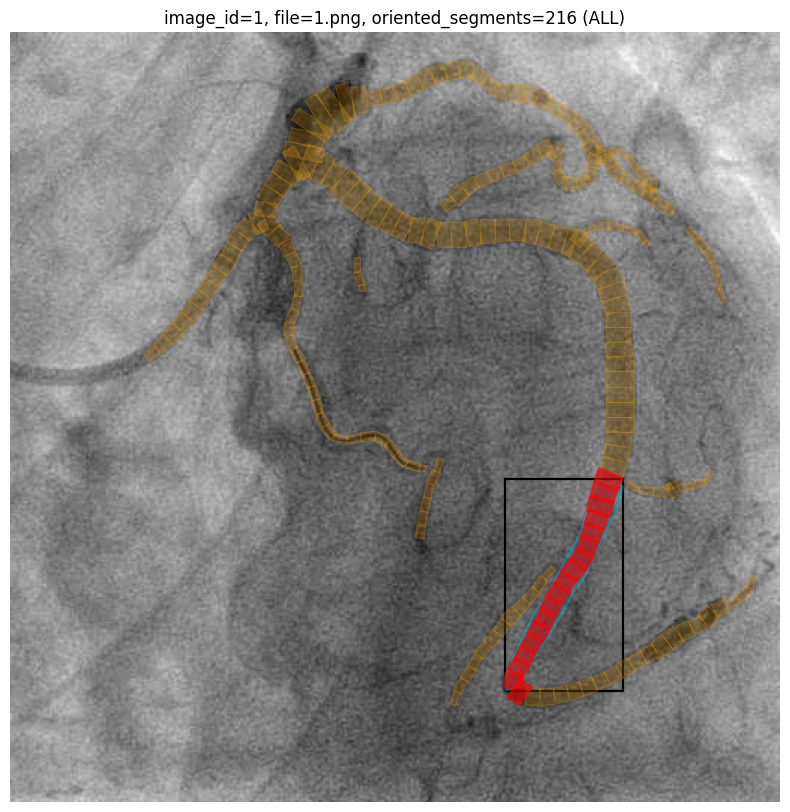

In [13]:
from matplotlib.patches import Polygon, Rectangle


def parse_json_points(value):
    if isinstance(value, str):
        return np.asarray(json.loads(value), dtype=float)
    if isinstance(value, list):
        return np.asarray(value, dtype=float)
    return np.empty((0, 2), dtype=float)


def draw_coco_segmentation(ax, segmentation, color="cyan", alpha=0.28, linewidth=1.5):
    if segmentation is None:
        return
    if isinstance(segmentation, str):
        try:
            segmentation = json.loads(segmentation)
        except Exception:
            return
    if not isinstance(segmentation, list):
        return

    for poly in segmentation:
        arr = np.asarray(poly, dtype=float).reshape(-1, 2)
        if len(arr) < 3:
            continue
        ax.add_patch(
            Polygon(
                arr,
                closed=True,
                fill=True,
                edgecolor=color,
                facecolor=color,
                linewidth=linewidth,
                alpha=alpha,
            )
        )


def show_oriented_segments(
    image_id: int | None = None,
    file_name: str | None = None,
    max_segments: int | None = None,
    show_only_positive_neighborhood: bool = False,
    draw_bbox: bool = True,
    draw_segmentation: bool = True,
    figsize=(10, 10),
):
    """
    Pokazuje oriented segmenty dla danego obrazu.

    Domyślnie pokazuje WSZYSTKIE segmenty zapisane w df dla image_id.
    Uwaga: jeśli show_only_positive_neighborhood=True, wtedy celowo pokazuje tylko okolice label=1.
    """
    if "df" not in globals() or len(df) == 0:
        raise RuntimeError("Brak df. Uruchom generowanie danych.")

    if image_id is None and file_name is None:
        positives = df[df["label"] == 1]
        if len(positives):
            image_id = int(positives.iloc[0]["image_id"])
        else:
            image_id = int(df.iloc[0]["image_id"])

    if file_name is not None:
        image_id = image_id_by_file[file_name]

    image_id = int(image_id)
    img_info = image_by_id[image_id]
    file_name = img_info["file_name"]
    image_path = IMAGE_DIR / file_name

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(image_path)

    sub_all = df[df["image_id"].astype(int) == image_id].copy()
    sub = sub_all.copy()

    if show_only_positive_neighborhood and len(sub) and (sub["label"] == 1).any():
        pos = sub[sub["label"] == 1]
        xmin = pos["axis_bbox_x_min"].min() - 60
        xmax = pos["axis_bbox_x_max"].max() + 60
        ymin = pos["axis_bbox_y_min"].min() - 60
        ymax = pos["axis_bbox_y_max"].max() + 60
        sub = sub[(sub["center_x"].between(xmin, xmax)) & (sub["center_y"].between(ymin, ymax))]

    if max_segments is not None and len(sub) > max_segments:
        pos = sub[sub["label"] == 1]
        neg = sub[sub["label"] == 0]
        n_neg = max(0, max_segments - len(pos))
        neg = neg.sample(min(n_neg, len(neg)), random_state=0)
        sub = pd.concat([pos, neg]).sort_index()

    print(f"image_id={image_id}, file={file_name}")
    print(f"Wszystkie segmenty w df dla tego obrazu: {len(sub_all)}")
    print(f"Segmenty aktualnie rysowane: {len(sub)}")
    if len(sub_all):
        print("label counts all:")
        print(sub_all["label"].value_counts(dropna=False).sort_index())

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap="gray")
    suffix = "ALL" if not show_only_positive_neighborhood else "positive neighborhood"
    ax.set_title(f"image_id={image_id}, file={file_name}, oriented_segments={len(sub)} ({suffix})")
    ax.axis("off")

    if draw_segmentation:
        sten_mask = stenosis_mask_by_image.get(image_id)
        if sten_mask is not None and sten_mask.sum() > 0:
            masked = np.ma.masked_where(sten_mask == 0, sten_mask)
            ax.imshow(masked, alpha=0.22)

    for ann in anns_by_image.get(image_id, []):
        if draw_bbox:
            x, y, w, h = ann["bbox_xywh"]
            ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=1.6, edgecolor="black"))
        if draw_segmentation:
            draw_coco_segmentation(ax, ann.get("segmentation"), color="cyan", alpha=0.20)

    if len(sub):
        for _, r in sub.sort_values("label").iterrows():
            verts = parse_json_points(r["oriented_box_vertices_xy"])
            if len(verts) != 4:
                continue
            if int(r["label"]) == 1:
                edgecolor = "red"
                linewidth = 1.8
                alpha = 0.55
            else:
                edgecolor = "orange"
                linewidth = 0.8
                alpha = 0.20
            ax.add_patch(
                Polygon(
                    verts,
                    closed=True,
                    fill=True,
                    edgecolor=edgecolor,
                    facecolor=edgecolor,
                    alpha=alpha,
                    linewidth=linewidth,
                )
            )

    plt.show()

show_oriented_segments(image_id=1, max_segments=None, show_only_positive_neighborhood=False)


## 12b. Diagnostyka pełnego pipeline'u dla jednego obrazu

Ta komórka pokazuje, czy problem jest w segmencie rysowania, w masce, w skeletonie, czy w grafie.

Panele:

1. oryginalny obraz + bbox/polygon stenosis,
2. maska segmentacji zapisana przez pipeline,
3. skeleton finalny po junction cleanup,
4. wszystkie oriented segmenty zapisane w `df` dla danego obrazu.


image_id=1, file=1.png
annotations: 1
oriented segments in df: 216
mask: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_mask.png exists= True
skeleton raw: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_skeleton_raw.png exists= True
skeleton pruned: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_skeleton_pruned.png exists= True
skeleton final: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_skeleton_final.png exists= True
label counts:
label
0    198
1     18
Name: count, dtype: int64
branch counts:
branch_id
0     26
1     16
2      1
3      4
4      4
5      5
6     21
7      1
8      1
9      3
10    13
11    25
12     6
13     7
14    54
15     3
16     6
17     3
18     1
19     4
20    12
Name: count, dtype: int64


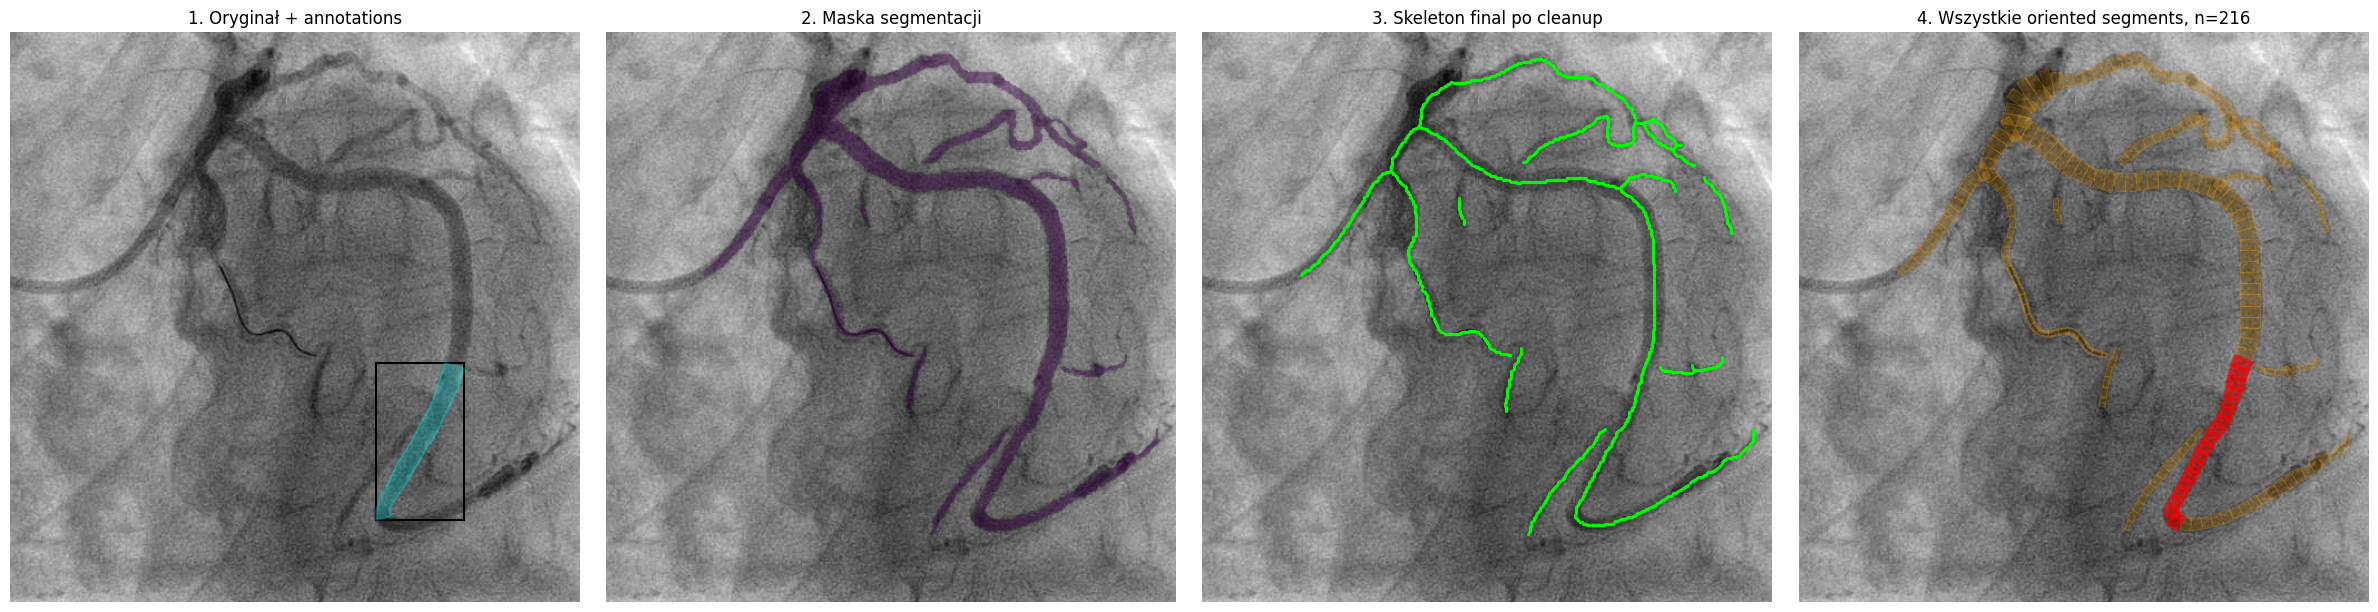

In [14]:
def read_debug_gray(image_id: int, name: str):
    p = DEBUG_DIR / f"{image_id}_{name}.png"
    if not p.exists():
        return None, p
    arr = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    return arr, p


def show_pipeline_debug(image_id: int = 1):
    image_id = int(image_id)
    img_info = image_by_id[image_id]
    file_name = img_info["file_name"]
    image_path = IMAGE_DIR / file_name
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(image_path)

    mask, mask_path = read_debug_gray(image_id, "mask")
    skel_raw, skel_raw_path = read_debug_gray(image_id, "skeleton_raw")
    skel_pruned, skel_pruned_path = read_debug_gray(image_id, "skeleton_pruned")
    skel_final, skel_final_path = read_debug_gray(image_id, "skeleton_final")

    sub = df[df["image_id"].astype(int) == image_id].copy()
    anns = anns_by_image.get(image_id, [])

    print(f"image_id={image_id}, file={file_name}")
    print(f"annotations: {len(anns)}")
    print(f"oriented segments in df: {len(sub)}")
    print("mask:", mask_path, "exists=", mask is not None)
    print("skeleton raw:", skel_raw_path, "exists=", skel_raw is not None)
    print("skeleton pruned:", skel_pruned_path, "exists=", skel_pruned is not None)
    print("skeleton final:", skel_final_path, "exists=", skel_final is not None)
    if len(sub):
        print("label counts:")
        print(sub["label"].value_counts(dropna=False).sort_index())
        print("branch counts:")
        print(sub["branch_id"].value_counts().sort_index())

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # 1. Original + annotations
    ax = axes[0]
    ax.imshow(img, cmap="gray")
    ax.set_title("1. Oryginał + annotations")
    ax.axis("off")
    for ann in anns:
        x, y, w, h = ann["bbox_xywh"]
        ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=1.5, edgecolor="black"))
        draw_coco_segmentation(ax, ann.get("segmentation"), color="cyan", alpha=0.25)

    # 2. Mask
    ax = axes[1]
    ax.imshow(img, cmap="gray")
    ax.set_title("2. Maska segmentacji")
    ax.axis("off")
    if mask is not None:
        ax.imshow(np.ma.masked_where(mask == 0, mask), alpha=0.35)
    else:
        ax.text(10, 25, "Brak maski debug.\nUruchom generowanie df ponownie.", color="yellow", bbox=dict(facecolor="black", alpha=0.7))

    # 3. Skeleton final
    ax = axes[2]
    ax.imshow(img, cmap="gray")
    ax.set_title("3. Skeleton final po cleanup")
    ax.axis("off")
    if skel_final is not None:
        ys, xs = np.where(skel_final > 0)
        ax.scatter(xs, ys, s=2, c="lime", alpha=0.8)
    else:
        ax.text(10, 25, "Brak skeleton_final debug.\nUruchom generowanie df ponownie.", color="yellow", bbox=dict(facecolor="black", alpha=0.7))

    # 4. All oriented segments
    ax = axes[3]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"4. Wszystkie oriented segments, n={len(sub)}")
    ax.axis("off")
    for _, r in sub.sort_values("label").iterrows():
        verts = parse_json_points(r["oriented_box_vertices_xy"])
        if len(verts) != 4:
            continue
        if int(r["label"]) == 1:
            color = "red"
            alpha = 0.55
            lw = 1.8
        else:
            color = "orange"
            alpha = 0.20
            lw = 0.7
        ax.add_patch(Polygon(verts, closed=True, fill=True, edgecolor=color, facecolor=color, alpha=alpha, linewidth=lw))

    plt.tight_layout()
    plt.show()


show_pipeline_debug(image_id=1)


## 13. Podgląd samych anotacji `segmentation` z `train.json`

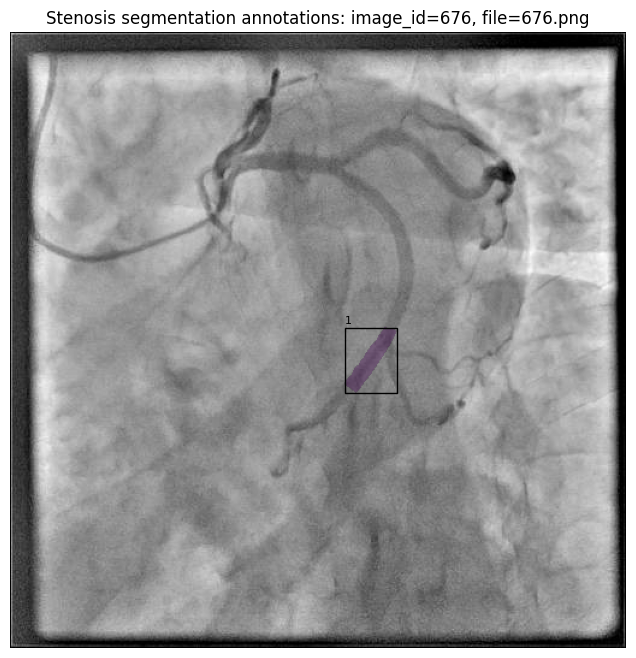

In [15]:
def show_stenosis_annotations(image_id: int | None = None, file_name: str | None = None):
    if image_id is None and file_name is None:
        image_id = next(iter(anns_by_image.keys()))
    if file_name is not None:
        image_id = image_id_by_file[file_name]

    img_info = image_by_id[int(image_id)]
    file_name = img_info["file_name"]
    image_path = IMAGE_DIR / file_name
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Stenosis segmentation annotations: image_id={image_id}, file={file_name}")
    ax.axis("off")

    for annm in ann_masks_by_image.get(int(image_id), []):
        mask = annm["mask"]
        masked = np.ma.masked_where(mask == 0, mask)
        ax.imshow(masked, alpha=0.35)

        x, y, w, h = annm["bbox_xywh"]
        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=1.0)
        ax.add_patch(rect)
        ax.text(x, max(0, y - 3), str(annm["ann_id"]), fontsize=8)

    plt.show()


show_stenosis_annotations(image_id=next(iter(anns_by_image.keys())))


## 14. Minimalny sanity-check klasyfikatora

To tylko szybki test, czy CSV nadaje się do uczenia. Do właściwych eksperymentów dobierz model, sampling i walidację grupowaną po `image_id`.

In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

feature_cols = [
    "center_x",
    "center_y",
    "segment_length_px",
    "patch_width_px",
    "patch_area_px",
    "angle_deg",
    "mean_diameter",
    "min_diameter",
    "max_diameter",
    "std_diameter",
    "diameter_drop",
    "branch_distance",
    "branch_euclidean_distance",
    "branch_tortuosity",
    "branch_type",
]

if "train_ready_df" not in globals():
    train_ready_df = df[[*feature_cols, "image_id", "label"]].copy()

clf_df = train_ready_df.dropna(subset=feature_cols + ["label", "image_id"]).copy()
print("clf_df:", clf_df.shape)
print(clf_df["label"].value_counts().sort_index())

if len(clf_df["label"].unique()) < 2:
    print("Za mało klas do treningu. Zwiększ FAST_DEV_LIMIT albo wygeneruj pełniejszy zbiór.")
else:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(splitter.split(clf_df, clf_df["label"], groups=clf_df["image_id"]))

    X_train = clf_df.iloc[train_idx][feature_cols]
    y_train = clf_df.iloc[train_idx]["label"].astype(int)
    X_test = clf_df.iloc[test_idx][feature_cols]
    y_test = clf_df.iloc[test_idx]["label"].astype(int)

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=4))

    importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    display(importances.to_frame("importance"))


clf_df: (194729, 22)
label
0    174428
1     20301
Name: count, dtype: int64
[[41943   355]
 [ 4707   367]]
              precision    recall  f1-score   support

           0     0.8991    0.9916    0.9431     42298
           1     0.5083    0.0723    0.1266      5074

    accuracy                         0.8931     47372
   macro avg     0.7037    0.5320    0.5349     47372
weighted avg     0.8572    0.8931    0.8556     47372



,importance
center_x,0.134513
max_diameter,0.096122
mean_diameter,0.087293
patch_width_px,0.082268
center_y,0.081167
branch_tortuosity,0.071679
patch_area_px,0.070206
branch_euclidean_distance,0.064649
branch_distance,0.064494
angle_deg,0.055206


## 15. XGBoost na obróconych segmentach — wersja po refaktorze

Od tego miejsca notebook jest tylko cienką warstwą eksperymentu. Logika XGBoosta siedzi w plikach biblioteki:

```text
src/coronary_analysis/models/xgboost_segments.py
src/coronary_analysis/metrics/enrichment.py
src/coronary_analysis/visualization/xgboost_segments.py
```

W notebooku zostają: importy, odpalenie treningu, `display(...)`, wykresy i zapis wyników.

### 15.1. Importy z biblioteki

In [17]:
from coronary_analysis.models.xgboost_segments import (
    save_xgboost_outputs,
    train_xgboost_on_segments,
)
from coronary_analysis.metrics.enrichment import enrichment_factor_table
from coronary_analysis.visualization.xgboost_segments import (
    plot_feature_importance,
    plot_precision_recall,
    plot_roc,
    plot_confusion_matrix,
    plot_xgb_predictions_for_image,
)

### 15.2. Trening modelu

`train_xgboost_on_segments(...)` robi teraz rzeczy, które wcześniej były rozbite po wielu komórkach: przygotowanie danych, cechy sąsiednich segmentów, split po `image_id`, trening, dobór thresholda, metryki, predykcje i feature importance.

In [18]:
assert "df" in globals(), "Brak df — uruchom wcześniejsze komórki generujące dataset."
assert len(df) > 0, "df jest pusty — sprawdź generowanie segmentów."

result = train_xgboost_on_segments(
    df,
    random_state=42,
    target_recall=0.85,
)

print("feature_cols:", len(result.feature_cols))
print("split_seed:", result.split.seed)
print("selected_threshold:", result.selected_threshold)

[0]	validation_0-aucpr:0.25626	validation_1-aucpr:0.23855
[50]	validation_0-aucpr:0.34430	validation_1-aucpr:0.31783
[100]	validation_0-aucpr:0.37486	validation_1-aucpr:0.34070
[150]	validation_0-aucpr:0.39596	validation_1-aucpr:0.35415
[200]	validation_0-aucpr:0.41486	validation_1-aucpr:0.36252
[250]	validation_0-aucpr:0.42734	validation_1-aucpr:0.36921
[300]	validation_0-aucpr:0.43752	validation_1-aucpr:0.37469
[350]	validation_0-aucpr:0.44682	validation_1-aucpr:0.37846
[400]	validation_0-aucpr:0.45388	validation_1-aucpr:0.38215
[450]	validation_0-aucpr:0.46019	validation_1-aucpr:0.38523
[500]	validation_0-aucpr:0.46544	validation_1-aucpr:0.38778
[550]	validation_0-aucpr:0.47022	validation_1-aucpr:0.38822
[600]	validation_0-aucpr:0.47448	validation_1-aucpr:0.38918
[650]	validation_0-aucpr:0.47857	validation_1-aucpr:0.38972
[700]	validation_0-aucpr:0.48232	validation_1-aucpr:0.38968
[750]	validation_0-aucpr:0.48557	validation_1-aucpr:0.39006
[799]	validation_0-aucpr:0.48935	validation

### 15.3. Metryki

In [19]:
print("VAL @ selected threshold")
print(result.metrics["val"]["confusion_matrix"])
print(result.metrics["val"]["classification_report"])
print("ROC-AUC:", result.metrics["val"]["roc_auc"])
print("AUPRC:", result.metrics["val"]["average_precision"])

print("\nTEST @ selected threshold")
print(result.metrics["test"]["confusion_matrix"])
print(result.metrics["test"]["classification_report"])
print("ROC-AUC:", result.metrics["test"]["roc_auc"])
print("AUPRC:", result.metrics["test"]["average_precision"])

print("\nTEST @ threshold = 0.5")
print(result.metrics["test_at_0_5"]["confusion_matrix"])
print(result.metrics["test_at_0_5"]["classification_report"])

VAL @ selected threshold
[[18490  7673]
 [  442  2508]]
              precision    recall  f1-score   support

           0     0.9767    0.7067    0.8200     26163
           1     0.2463    0.8502    0.3820      2950

    accuracy                         0.7213     29113
   macro avg     0.6115    0.7784    0.6010     29113
weighted avg     0.9027    0.7213    0.7757     29113

ROC-AUC: 0.8550297904208104
AUPRC: 0.3920530742595279

TEST @ selected threshold
[[18703  7475]
 [  477  2507]]
              precision    recall  f1-score   support

           0     0.9751    0.7145    0.8247     26178
           1     0.2512    0.8401    0.3867      2984

    accuracy                         0.7273     29162
   macro avg     0.6131    0.7773    0.6057     29162
weighted avg     0.9010    0.7273    0.7799     29162

ROC-AUC: 0.8466530603435297
AUPRC: 0.3563546522263008

TEST @ threshold = 0.5
[[19359  6819]
 [  550  2434]]
              precision    recall  f1-score   support

           0  

### 15.4. Zapis predykcji i feature importance

Zapisano predykcje: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/xgboost_oriented_segments_predictions.csv
Zapisano feature importance: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/xgboost_feature_importance.csv


,feature,importance
16,max_diameter,0.168450
5,patch_width_px,0.111248
34,neighbor_mean_patch_width_px,0.061718
14,mean_diameter,0.041181
8,axis_bbox_x_min,0.035401
52,neighbor_mean_mean_diameter,0.033617
22,branch_type,0.030463
57,next_min_diameter,0.027966
40,neighbor_mean_patch_area_px,0.026806
2,center_x,0.023807


<Axes: title={'center': 'XGBoost feature importance — top 30'}, xlabel='Importance'>

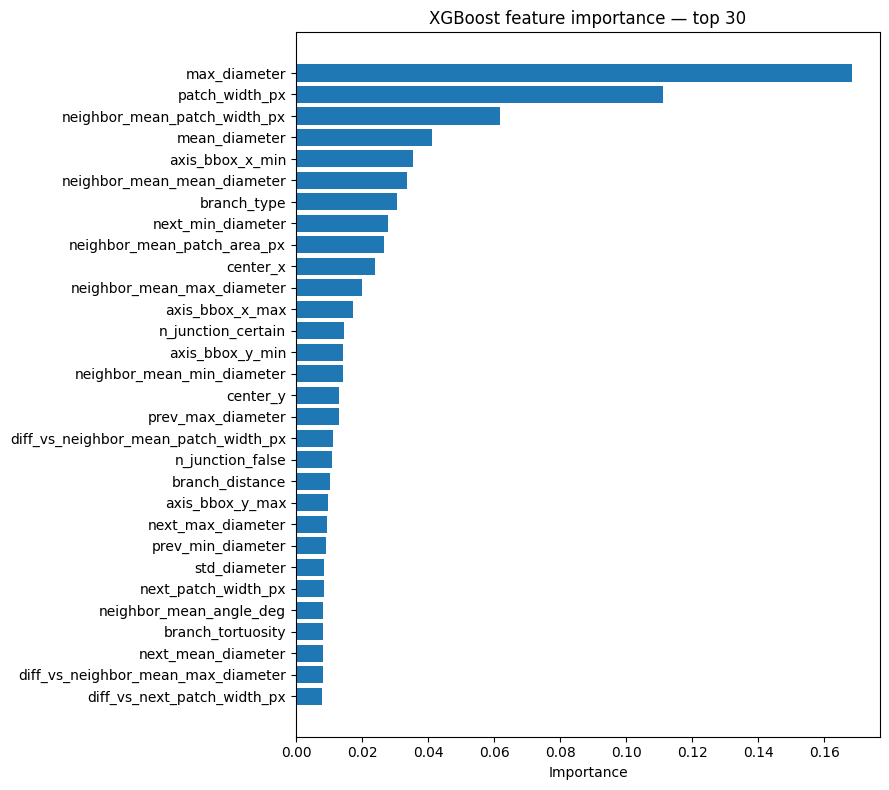

In [20]:
pred_csv, importance_csv = save_xgboost_outputs(result, OUTPUT_DIR)
print("Zapisano predykcje:", pred_csv)
print("Zapisano feature importance:", importance_csv)

display(result.importance.head(40))
plot_feature_importance(result.importance)

### 15.5. Krzywe PR/ROC i confusion matrix

<Axes: title={'center': 'Confusion matrix @ 0.462'}, xlabel='Predicted label', ylabel='True label'>

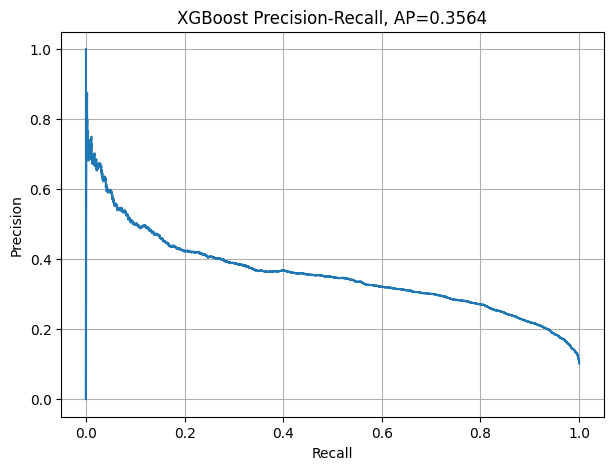

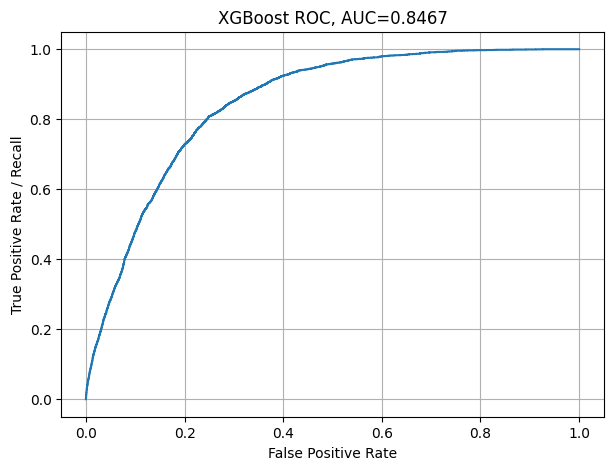

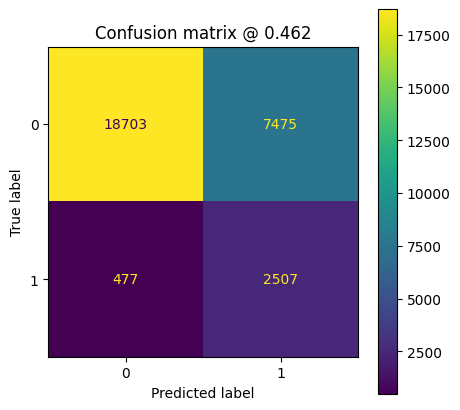

In [21]:
xgb_df = result.dataframe
split = result.split

y_test = xgb_df.iloc[split.test_idx]["label"].astype(int)
proba_test = result.predictions.iloc[split.test_idx]["xgb_pred_proba"].to_numpy()
pred_test = (proba_test >= result.selected_threshold).astype(int)

plot_precision_recall(
    y_test,
    proba_test,
    average_precision=result.metrics["test"]["average_precision"],
)
plot_roc(
    y_test,
    proba_test,
    roc_auc=result.metrics["test"]["roc_auc"],
)
plot_confusion_matrix(
    y_test,
    pred_test,
    title=f"Confusion matrix @ {result.selected_threshold:.3f}",
)

### 15.6. Enrichment Factor

In [22]:
ef_results = enrichment_factor_table(y_test, proba_test)
display(ef_results)

ef_path = OUTPUT_DIR / "xgboost_enrichment_factor_test.csv"
ef_results.to_csv(ef_path, index=False)
print("Zapisano:", ef_path)

,top_percent,n_top,positives_in_top,positive_rate_top,baseline_positive_rate,enrichment_factor,recall_at_top
0,1.0,292,166,0.568493,0.102325,5.555763,0.055630
1,2.0,584,292,0.500000,0.102325,4.886394,0.097855
2,5.0,1459,618,0.423578,0.102325,4.139536,0.207105
3,10.0,2917,1068,0.366130,0.102325,3.578107,0.357909
4,20.0,5833,1849,0.316990,0.102325,3.097872,0.619638


Zapisano: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/xgboost_enrichment_factor_test.csv


### 15.7. Wizualizacja predykcji na jednym obrazie

pred,0,1
true,,
0,82,25
1,1,67


,image_id,file_name,branch_id,oriented_segment_id,local_segment_id,arc_start_px,arc_end_px,center_x,center_y,segment_length_px,...,diff_vs_prev_diameter_drop,diff_vs_next_diameter_drop,diff_vs_neighbor_mean_diameter_drop,mean_diameter_ratio_to_neighbors,min_diameter_ratio_to_neighbor_mean,local_stenosis_score,split,xgb_pred_proba,xgb_pred_label,pred
170680,876,876.png,0,0,0,0.0,10.0,198.532533,40.853161,9.715713,...,0.000000,0.182387,0.182387,0.897146,0.639160,0.360840,test,0.440364,0.0,0
170681,876,876.png,0,1,1,10.0,20.0,191.291001,46.945179,9.833259,...,-0.182387,0.024214,-0.079087,1.125588,1.007203,-0.007203,test,0.760877,1.0,1
170682,876,876.png,0,2,2,20.0,30.0,182.591004,50.083665,9.955222,...,-0.024214,0.024432,0.000109,0.970467,0.891896,0.108104,test,0.666818,1.0,1
170683,876,876.png,0,3,3,30.0,40.0,173.241073,51.653070,9.799553,...,-0.024432,0.039909,0.007738,0.979657,0.924277,0.075723,test,0.599762,1.0,1
170684,876,876.png,0,4,4,40.0,50.0,163.836321,53.090125,9.951798,...,-0.039909,-0.086374,-0.063141,1.022559,1.005564,-0.005564,test,0.617309,1.0,1
170685,876,876.png,0,5,5,50.0,60.0,154.228476,54.036872,9.899195,...,0.086374,-0.029469,0.028453,0.939599,0.842825,0.157175,test,0.681135,1.0,1
170686,876,876.png,0,6,6,60.0,70.0,145.036088,55.986619,9.976490,...,0.029469,-0.003699,0.012885,0.920689,0.798732,0.201268,test,0.727159,1.0,1
170687,876,876.png,0,7,7,70.0,80.0,136.695428,59.992621,9.805210,...,0.003699,0.034171,0.018935,1.007101,0.869972,0.130028,test,0.812551,1.0,1
170688,876,876.png,0,8,8,80.0,90.0,129.978535,66.807343,9.860980,...,-0.034171,0.001277,-0.016447,1.073224,0.963765,0.036235,test,0.821779,1.0,1
170689,876,876.png,0,9,9,90.0,100.0,123.193116,73.996730,9.952267,...,-0.001277,0.079616,0.039169,1.051386,0.945497,0.054503,test,0.760314,1.0,1


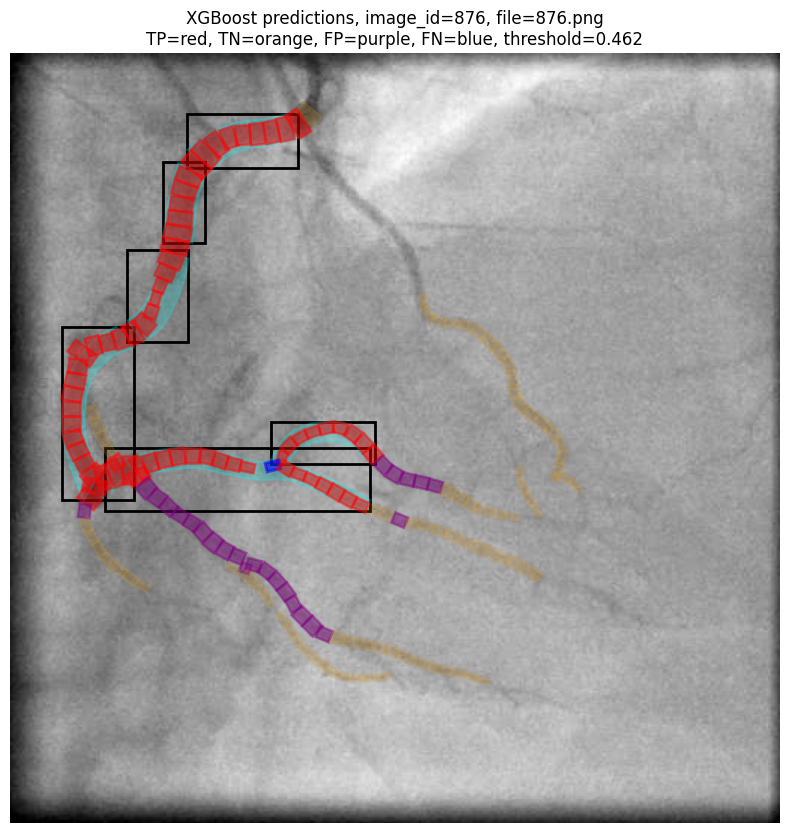

In [23]:
ax, sub, counts = plot_xgb_predictions_for_image(
    predictions_df=result.predictions,
    image_by_id=image_by_id,
    anns_by_image=anns_by_image,
    image_dir=IMAGE_DIR,
    threshold=result.selected_threshold,
)

display(counts)
display(sub.head(20))